In [80]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [29]:
df_car = pd.read_csv("Car or van.csv")
df_age = pd.read_csv("age.csv")
df_distance_travelled = pd.read_csv("Distance_travelled_to _work.csv")
df_economic_act = pd.read_csv("economic activity.csv")

## Data Cleaning & Feature Selection
### Car or Van Availability

In [30]:
df_car.head(5)

,date,geography,geography code,Rural Urban,Cars: All categories: Car or van availability; measures: Value,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,Cars: 2 cars or vans in household; measures: Value,Cars: 3 cars or vans in household; measures: Value,Cars: 4 or more cars or vans in household; measures: Value,Cars: sum of All cars or vans in the area; measures: Value
0,2011,Darlington,E06000005,Total,46670,13052,20682,10450,1962,524,49794
1,2011,County Durham,E06000047,Total,223803,60926,96086,52740,10775,3276,248586
2,2011,Hartlepool,E06000001,Total,40434,14268,16573,7662,1535,396,38269
3,2011,Middlesbrough,E06000002,Total,57203,21488,22963,10207,1945,600,51821
4,2011,Northumberland,E06000057,Total,138534,30543,60875,36916,7671,2529,168974


In [31]:
df_car.info()

<class 'pandas.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 11 columns):
 #   Column                                                          Non-Null Count  Dtype
---  ------                                                          --------------  -----
 0   date                                                            174 non-null    int64
 1   geography                                                       174 non-null    str  
 2   geography code                                                  174 non-null    str  
 3   Rural Urban                                                     174 non-null    str  
 4   Cars: All categories: Car or van availability; measures: Value  174 non-null    int64
 5   Cars: No cars or vans in household; measures: Value             174 non-null    int64
 6   Cars: 1 car or van in household; measures: Value                174 non-null    int64
 7   Cars: 2 cars or vans in household; measures: Value              174 non-null    in

In [32]:
df_car.isna().sum()

date                                                              0
geography                                                         0
geography code                                                    0
Rural Urban                                                       0
Cars: All categories: Car or van availability; measures: Value    0
Cars: No cars or vans in household; measures: Value               0
Cars: 1 car or van in household; measures: Value                  0
Cars: 2 cars or vans in household; measures: Value                0
Cars: 3 cars or vans in household; measures: Value                0
Cars: 4 or more cars or vans in household; measures: Value        0
Cars: sum of All cars or vans in the area; measures: Value        0
dtype: int64

In [33]:
df_car.shape

(174, 11)

In [34]:
df_car = df_car.drop(["date", "Cars: All categories: Car or van availability; measures: Value", "Cars: sum of All cars or vans in the area; measures: Value"], axis = 1)

In [35]:
df_car.head(5)

,geography,geography code,Rural Urban,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,Cars: 2 cars or vans in household; measures: Value,Cars: 3 cars or vans in household; measures: Value,Cars: 4 or more cars or vans in household; measures: Value
0,Darlington,E06000005,Total,13052,20682,10450,1962,524
1,County Durham,E06000047,Total,60926,96086,52740,10775,3276
2,Hartlepool,E06000001,Total,14268,16573,7662,1535,396
3,Middlesbrough,E06000002,Total,21488,22963,10207,1945,600
4,Northumberland,E06000057,Total,30543,60875,36916,7671,2529


In [150]:
df_car_cp = df_car.copy()

In [152]:
numeric_columns = df_car_cp.select_dtypes(include = "number").columns

In [154]:
df_car_cp[numeric_columns] = df_car_cp[numeric_columns].div(df_car_cp[numeric_columns].sum(axis =1), axis =0)

In [155]:
df_car_cp.head(4)

,geography,geography code,Rural Urban,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,Cars: 2 cars or vans in household; measures: Value,Cars: 3 cars or vans in household; measures: Value,Cars: 4 or more cars or vans in household; measures: Value
0,Darlington,E06000005,Total,0.279666,0.443154,0.223913,0.042040,0.011228
1,County Durham,E06000047,Total,0.272230,0.429333,0.235654,0.048145,0.014638
2,Hartlepool,E06000001,Total,0.352871,0.409878,0.189494,0.037963,0.009794
3,Middlesbrough,E06000002,Total,0.375645,0.401430,0.178435,0.034002,0.010489


### Age

In [36]:
df_age.head(5)

,date,geography,geography code,Rural Urban,Age: All usual residents; measures: Value,Age: Age 0 to 4; measures: Value,Age: Age 5 to 7; measures: Value,Age: Age 8 to 9; measures: Value,Age: Age 10 to 14; measures: Value,Age: Age 15; measures: Value,...,Age: Age 25 to 29; measures: Value,Age: Age 30 to 44; measures: Value,Age: Age 45 to 59; measures: Value,Age: Age 60 to 64; measures: Value,Age: Age 65 to 74; measures: Value,Age: Age 75 to 84; measures: Value,Age: Age 85 to 89; measures: Value,Age: Age 90 and over; measures: Value,Age: Mean Age; measures: Value,Age: Median Age; measures: Value
0,2011,Darlington,E06000005,Total,105564,6579,3790,2284,6224,1330,...,6607,20917,21560,6685,9717,6172,1740,810,40.2,41.0
1,2011,County Durham,E06000047,Total,513242,28574,15818,9841,27869,5882,...,30628,96150,108200,35395,50883,30635,7321,3506,41.0,42.0
2,2011,Hartlepool,E06000001,Total,92028,5698,3202,1990,5653,1257,...,5622,16869,19326,5837,8174,5568,1323,533,39.8,40.0
3,2011,Middlesbrough,E06000002,Total,138412,9431,5178,3098,8485,1811,...,9765,25414,27065,7531,10833,7393,1658,807,37.8,37.0
4,2011,Northumberland,E06000057,Total,316028,16003,9863,6482,17677,3841,...,16187,56156,71135,24533,34366,21018,5233,2687,42.8,45.0


In [37]:
df_age.shape

(174, 23)

In [38]:
df_age.info()

<class 'pandas.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 23 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   date                                       174 non-null    int64  
 1   geography                                  174 non-null    str    
 2   geography code                             174 non-null    str    
 3   Rural Urban                                174 non-null    str    
 4   Age: All usual residents; measures: Value  174 non-null    int64  
 5   Age: Age 0 to 4; measures: Value           174 non-null    int64  
 6   Age: Age 5 to 7; measures: Value           174 non-null    int64  
 7   Age: Age 8 to 9; measures: Value           174 non-null    int64  
 8   Age: Age 10 to 14; measures: Value         174 non-null    int64  
 9   Age: Age 15; measures: Value               174 non-null    int64  
 10  Age: Age 16 to 17; measures: Value   

In [39]:
df_age = df_age.drop(["date", "Age: All usual residents; measures: Value","Age: Mean Age; measures: Value", "Age: Median Age; measures: Value" ], axis = 1)

In [40]:
df_age.head(5)

,geography,geography code,Rural Urban,Age: Age 0 to 4; measures: Value,Age: Age 5 to 7; measures: Value,Age: Age 8 to 9; measures: Value,Age: Age 10 to 14; measures: Value,Age: Age 15; measures: Value,Age: Age 16 to 17; measures: Value,Age: Age 18 to 19; measures: Value,Age: Age 20 to 24; measures: Value,Age: Age 25 to 29; measures: Value,Age: Age 30 to 44; measures: Value,Age: Age 45 to 59; measures: Value,Age: Age 60 to 64; measures: Value,Age: Age 65 to 74; measures: Value,Age: Age 75 to 84; measures: Value,Age: Age 85 to 89; measures: Value,Age: Age 90 and over; measures: Value
0,Darlington,E06000005,Total,6579,3790,2284,6224,1330,2721,2357,6071,6607,20917,21560,6685,9717,6172,1740,810
1,County Durham,E06000047,Total,28574,15818,9841,27869,5882,12107,15278,35155,30628,96150,108200,35395,50883,30635,7321,3506
2,Hartlepool,E06000001,Total,5698,3202,1990,5653,1257,2570,2451,5955,5622,16869,19326,5837,8174,5568,1323,533
3,Middlesbrough,E06000002,Total,9431,5178,3098,8485,1811,3747,4506,11690,9765,25414,27065,7531,10833,7393,1658,807
4,Northumberland,E06000057,Total,16003,9863,6482,17677,3841,7631,6992,16224,16187,56156,71135,24533,34366,21018,5233,2687


In [156]:
df_age_cp = df_age.copy()

In [157]:
numeric_columns = df_age_cp.select_dtypes(include="number").columns

In [159]:
df_age_cp[numeric_columns] = df_age_cp[numeric_columns].div(df_age_cp[numeric_columns].sum(axis =1), axis=0)

In [160]:
df_age_cp.head(5)

,geography,geography code,Rural Urban,Age: Age 0 to 4; measures: Value,Age: Age 5 to 7; measures: Value,Age: Age 8 to 9; measures: Value,Age: Age 10 to 14; measures: Value,Age: Age 15; measures: Value,Age: Age 16 to 17; measures: Value,Age: Age 18 to 19; measures: Value,Age: Age 20 to 24; measures: Value,Age: Age 25 to 29; measures: Value,Age: Age 30 to 44; measures: Value,Age: Age 45 to 59; measures: Value,Age: Age 60 to 64; measures: Value,Age: Age 65 to 74; measures: Value,Age: Age 75 to 84; measures: Value,Age: Age 85 to 89; measures: Value,Age: Age 90 and over; measures: Value
0,Darlington,E06000005,Total,0.062322,0.035902,0.021636,0.058959,0.012599,0.025776,0.022328,0.057510,0.062588,0.198145,0.204236,0.063327,0.092048,0.058467,0.016483,0.007673
1,County Durham,E06000047,Total,0.055674,0.030820,0.019174,0.054300,0.011460,0.023589,0.029768,0.068496,0.059676,0.187339,0.210817,0.068964,0.099140,0.059689,0.014264,0.006831
2,Hartlepool,E06000001,Total,0.061916,0.034794,0.021624,0.061427,0.013659,0.027926,0.026633,0.064709,0.061090,0.183303,0.210001,0.063426,0.088821,0.060503,0.014376,0.005792
3,Middlesbrough,E06000002,Total,0.068137,0.037410,0.022382,0.061302,0.013084,0.027071,0.032555,0.084458,0.070550,0.183611,0.195539,0.054410,0.078266,0.053413,0.011979,0.005830
4,Northumberland,E06000057,Total,0.050638,0.031209,0.020511,0.055935,0.012154,0.024147,0.022125,0.051337,0.051220,0.177693,0.225091,0.077629,0.108744,0.066507,0.016559,0.008502


### Distance Travelled To work

In [41]:
df_distance_travelled.info()

<class 'pandas.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 17 columns):
 #   Column                                                                                   Non-Null Count  Dtype  
---  ------                                                                                   --------------  -----  
 0   date                                                                                     174 non-null    int64  
 1   geography                                                                                174 non-null    str    
 2   geography code                                                                           174 non-null    str    
 3   Rural Urban                                                                              174 non-null    str    
 4   Distance travelled to work: All categories: Distance travelled to work; measures: Value  174 non-null    int64  
 5   Distance travelled to work: Less than 2km; measures: Value                 

In [42]:
df_distance_travelled.shape

(174, 17)

In [45]:
df_distance_travelled.isna().sum()

date                                                                                       0
geography                                                                                  0
geography code                                                                             0
Rural Urban                                                                                0
Distance travelled to work: All categories: Distance travelled to work; measures: Value    0
Distance travelled to work: Less than 2km; measures: Value                                 0
Distance travelled to work: 2km to less than 5km; measures: Value                          0
Distance travelled to work: 5km to less than 10km; measures: Value                         0
Distance travelled to work: 10km to less than 20km; measures: Value                        0
Distance travelled to work: 20km to less than 30km; measures: Value                        0
Distance travelled to work: 30km to less than 40km; measures: Value   

In [47]:
df_distance_travelled = df_distance_travelled.drop(["date", "Distance travelled to work: All categories: Distance travelled to work; measures: Value","Distance travelled to work: Total distance (km); measures: Value", "Distance travelled to work: Average distance (km); measures: Value"], axis = 1)

In [48]:
df_distance_travelled.head(5)

,geography,geography code,Rural Urban,Distance travelled to work: Less than 2km; measures: Value,Distance travelled to work: 2km to less than 5km; measures: Value,Distance travelled to work: 5km to less than 10km; measures: Value,Distance travelled to work: 10km to less than 20km; measures: Value,Distance travelled to work: 20km to less than 30km; measures: Value,Distance travelled to work: 30km to less than 40km; measures: Value,Distance travelled to work: 40km to less than 60km; measures: Value,Distance travelled to work: 60km and over; measures: Value,Distance travelled to work: Work mainly at or from home; measures: Value,Distance travelled to work: Other; measures: Value
0,Darlington,E06000005,Total,11433,12516,4226,5552,4410,793,1234,1502,4180,3168
1,County Durham,E06000047,Total,36588,31877,38010,51191,19810,6846,2222,5704,20652,14994
2,Hartlepool,E06000001,Total,8452,10557,3406,5707,1684,681,489,1154,2473,3164
3,Middlesbrough,E06000002,Total,10393,15799,11414,4137,1281,642,848,1733,3337,4963
4,Northumberland,E06000057,Total,25944,14491,19568,30255,12969,5666,4162,5593,17894,10359


In [161]:
df_dist_cp = df_distance_travelled.copy()
numeric_columns = df_dist_cp.select_dtypes(include="number").columns
df_dist_cp[numeric_columns] = df_dist_cp[numeric_columns].div(df_dist_cp[numeric_columns].sum(axis =1), axis=0)


In [162]:
df_dist_cp.head(4)

,geography,geography code,Rural Urban,Distance travelled to work: Less than 2km; measures: Value,Distance travelled to work: 2km to less than 5km; measures: Value,Distance travelled to work: 5km to less than 10km; measures: Value,Distance travelled to work: 10km to less than 20km; measures: Value,Distance travelled to work: 20km to less than 30km; measures: Value,Distance travelled to work: 30km to less than 40km; measures: Value,Distance travelled to work: 40km to less than 60km; measures: Value,Distance travelled to work: 60km and over; measures: Value,Distance travelled to work: Work mainly at or from home; measures: Value,Distance travelled to work: Other; measures: Value
0,Darlington,E06000005,Total,0.233260,0.255356,0.086220,0.113274,0.089974,0.016179,0.025176,0.030644,0.085282,0.064635
1,County Durham,E06000047,Total,0.160548,0.139876,0.166788,0.224626,0.086926,0.030040,0.009750,0.025029,0.090621,0.065794
2,Hartlepool,E06000001,Total,0.223793,0.279530,0.090185,0.151111,0.044589,0.018032,0.012948,0.030556,0.065480,0.083777
3,Middlesbrough,E06000002,Total,0.190533,0.289640,0.209251,0.075843,0.023484,0.011770,0.015546,0.031771,0.061177,0.090986


### Economic Activity

In [49]:
df_economic_act.head(5)

,date,geography,geography code,Rural Urban,Economic Activity: All categories: Economic activity; measures: Value,Economic Activity: Economically active: Total; measures: Value,Economic Activity: Economically active: Employee: Part-time; measures: Value,Economic Activity: Economically active: Employee: Full-time; measures: Value,Economic Activity: Economically active: Self-employed with employees: Part-time; measures: Value,Economic Activity: Economically active: Self-employed with employees: Full-time; measures: Value,Economic Activity: Economically active: Self-employed without employees: Part-time; measures: Value,Economic Activity: Economically active: Self-employed without employees: Full-time; measures: Value,Economic Activity: Economically active: Unemployed; measures: Value,Economic Activity: Economically active: Full-time student; measures: Value,Economic Activity: Economically inactive: Total; measures: Value,Economic Activity: Economically inactive: Retired; measures: Value,Economic Activity: Economically inactive: Student (including full-time students); measures: Value,Economic Activity: Economically inactive: Looking after home or family; measures: Value,Economic Activity: Economically inactive: Long-term sick or disabled; measures: Value,Economic Activity: Economically inactive: Other; measures: Value
0,2011,Darlington,E06000005,Total,76635,53443,11555,30337,234,1254,1289,2818,4002,1954,23192,12214,2742,3081,3737,1418
1,2011,County Durham,E06000047,Total,383796,247101,50595,143922,1052,5717,5799,12741,17013,10262,136695,65444,23837,14190,24887,8337
2,2011,Hartlepool,E06000001,Total,66804,43513,10092,22635,212,846,892,1855,5194,1787,23291,10621,3042,3265,4733,1630
3,2011,Middlesbrough,E06000002,Total,100551,63582,15063,31301,300,1068,1331,2472,7631,4416,36969,13922,7453,5569,6841,3184
4,2011,Northumberland,E06000057,Total,233224,158268,34368,86380,993,5351,5151,10568,10329,5128,74956,43897,8108,8368,10321,4262


In [51]:
df_economic_act.shape

(174, 20)

In [52]:
df_economic_act.isna().sum()

date                                                                                                   0
geography                                                                                              0
geography code                                                                                         0
Rural Urban                                                                                            0
Economic Activity: All categories: Economic activity; measures: Value                                  0
Economic Activity: Economically active: Total; measures: Value                                         0
Economic Activity: Economically active: Employee: Part-time; measures: Value                           0
Economic Activity: Economically active: Employee: Full-time; measures: Value                           0
Economic Activity: Economically active: Self-employed with employees: Part-time; measures: Value       0
Economic Activity: Economically active: Self-employed w

In [53]:
df_economic_act = df_economic_act.drop(["date", "Economic Activity: All categories: Economic activity; measures: Value", "Economic Activity: Economically active: Total; measures: Value", "Economic Activity: Economically inactive: Total; measures: Value"], axis = 1)

In [54]:
df_economic_act.head(4)

,geography,geography code,Rural Urban,Economic Activity: Economically active: Employee: Part-time; measures: Value,Economic Activity: Economically active: Employee: Full-time; measures: Value,Economic Activity: Economically active: Self-employed with employees: Part-time; measures: Value,Economic Activity: Economically active: Self-employed with employees: Full-time; measures: Value,Economic Activity: Economically active: Self-employed without employees: Part-time; measures: Value,Economic Activity: Economically active: Self-employed without employees: Full-time; measures: Value,Economic Activity: Economically active: Unemployed; measures: Value,Economic Activity: Economically active: Full-time student; measures: Value,Economic Activity: Economically inactive: Retired; measures: Value,Economic Activity: Economically inactive: Student (including full-time students); measures: Value,Economic Activity: Economically inactive: Looking after home or family; measures: Value,Economic Activity: Economically inactive: Long-term sick or disabled; measures: Value,Economic Activity: Economically inactive: Other; measures: Value
0,Darlington,E06000005,Total,11555,30337,234,1254,1289,2818,4002,1954,12214,2742,3081,3737,1418
1,County Durham,E06000047,Total,50595,143922,1052,5717,5799,12741,17013,10262,65444,23837,14190,24887,8337
2,Hartlepool,E06000001,Total,10092,22635,212,846,892,1855,5194,1787,10621,3042,3265,4733,1630
3,Middlesbrough,E06000002,Total,15063,31301,300,1068,1331,2472,7631,4416,13922,7453,5569,6841,3184


In [60]:
df_distance_travelled["Rural Urban"].unique()

<ArrowStringArray>
['Total']
Length: 1, dtype: str

In [163]:
df_eco_cp = df_economic_act.copy()
numeric_columns = df_eco_cp.select_dtypes(include="number").columns
df_eco_cp[numeric_columns] = df_eco_cp[numeric_columns].div(df_eco_cp[numeric_columns].sum(axis =1), axis=0)


In [254]:
df_eco_cp.head(5)

,geography,geography code,Rural Urban,Economic Activity: Economically active: Employee: Part-time; measures: Value,Economic Activity: Economically active: Employee: Full-time; measures: Value,Economic Activity: Economically active: Self-employed with employees: Part-time; measures: Value,Economic Activity: Economically active: Self-employed with employees: Full-time; measures: Value,Economic Activity: Economically active: Self-employed without employees: Part-time; measures: Value,Economic Activity: Economically active: Self-employed without employees: Full-time; measures: Value,Economic Activity: Economically active: Unemployed; measures: Value,Economic Activity: Economically active: Full-time student; measures: Value,Economic Activity: Economically inactive: Retired; measures: Value,Economic Activity: Economically inactive: Student (including full-time students); measures: Value,Economic Activity: Economically inactive: Looking after home or family; measures: Value,Economic Activity: Economically inactive: Long-term sick or disabled; measures: Value,Economic Activity: Economically inactive: Other; measures: Value
0,Darlington,E06000005,Total,0.150780,0.395864,0.003053,0.016363,0.016820,0.036772,0.052222,0.025497,0.159379,0.035780,0.040204,0.048764,0.018503
1,County Durham,E06000047,Total,0.131828,0.374996,0.002741,0.014896,0.015110,0.033197,0.044328,0.026738,0.170518,0.062109,0.036973,0.064844,0.021722
2,Hartlepool,E06000001,Total,0.151069,0.338827,0.003173,0.012664,0.013352,0.027768,0.077750,0.026750,0.158987,0.045536,0.048874,0.070849,0.024400
3,Middlesbrough,E06000002,Total,0.149805,0.311295,0.002984,0.010621,0.013237,0.024585,0.075892,0.043918,0.138457,0.074122,0.055385,0.068035,0.031666
4,Northumberland,E06000057,Total,0.147360,0.370374,0.004258,0.022944,0.022086,0.045313,0.044288,0.021987,0.188218,0.034765,0.035880,0.044254,0.018274


### Merging Columns

In [279]:
df_age_merge = df_age.drop(["geography", "Rural Urban"], axis = 1)
df_distance_travelled_merge = df_distance_travelled.drop(["geography", "Rural Urban"], axis = 1)
df_economic_act_merg =  df_economic_act.drop(["geography", "Rural Urban"], axis = 1)


In [280]:
df_age_merge_cp = df_age_cp.drop(["geography", "Rural Urban"], axis = 1)
df_distance_travelled_merge_cp = df_dist_cp.drop(["geography", "Rural Urban"], axis = 1)
df_economic_act_merg_cp =  df_eco_cp.drop(["geography", "Rural Urban"], axis = 1)

In [281]:
merged_df = df_car.merge(df_distance_travelled_merge, on = "geography code", how = "inner").merge(df_economic_act_merg, on = "geography code", how = "inner").merge(df_age_merge, on = "geography code", how = "inner")

In [282]:
merged_df_cp = df_car_cp.merge(df_distance_travelled_merge_cp, on = "geography code", how = "inner").merge(df_economic_act_merg_cp, on = "geography code", how = "inner").merge(df_age_merge_cp, on = "geography code", how = "inner")

In [283]:
merged_df.head(5)

,geography,geography code,Rural Urban,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,Cars: 2 cars or vans in household; measures: Value,Cars: 3 cars or vans in household; measures: Value,Cars: 4 or more cars or vans in household; measures: Value,Distance travelled to work: Less than 2km; measures: Value,Distance travelled to work: 2km to less than 5km; measures: Value,...,Age: Age 18 to 19; measures: Value,Age: Age 20 to 24; measures: Value,Age: Age 25 to 29; measures: Value,Age: Age 30 to 44; measures: Value,Age: Age 45 to 59; measures: Value,Age: Age 60 to 64; measures: Value,Age: Age 65 to 74; measures: Value,Age: Age 75 to 84; measures: Value,Age: Age 85 to 89; measures: Value,Age: Age 90 and over; measures: Value
0,Darlington,E06000005,Total,13052,20682,10450,1962,524,11433,12516,...,2357,6071,6607,20917,21560,6685,9717,6172,1740,810
1,County Durham,E06000047,Total,60926,96086,52740,10775,3276,36588,31877,...,15278,35155,30628,96150,108200,35395,50883,30635,7321,3506
2,Hartlepool,E06000001,Total,14268,16573,7662,1535,396,8452,10557,...,2451,5955,5622,16869,19326,5837,8174,5568,1323,533
3,Middlesbrough,E06000002,Total,21488,22963,10207,1945,600,10393,15799,...,4506,11690,9765,25414,27065,7531,10833,7393,1658,807
4,Northumberland,E06000057,Total,30543,60875,36916,7671,2529,25944,14491,...,6992,16224,16187,56156,71135,24533,34366,21018,5233,2687


In [168]:
merged_df_cp.head(5)

,geography,geography code,Rural Urban,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,Cars: 2 cars or vans in household; measures: Value,Cars: 3 cars or vans in household; measures: Value,Cars: 4 or more cars or vans in household; measures: Value,Distance travelled to work: Less than 2km; measures: Value,Distance travelled to work: 2km to less than 5km; measures: Value,...,Age: Age 18 to 19; measures: Value,Age: Age 20 to 24; measures: Value,Age: Age 25 to 29; measures: Value,Age: Age 30 to 44; measures: Value,Age: Age 45 to 59; measures: Value,Age: Age 60 to 64; measures: Value,Age: Age 65 to 74; measures: Value,Age: Age 75 to 84; measures: Value,Age: Age 85 to 89; measures: Value,Age: Age 90 and over; measures: Value
0,Darlington,E06000005,Total,0.279666,0.443154,0.223913,0.042040,0.011228,0.233260,0.255356,...,0.022328,0.057510,0.062588,0.198145,0.204236,0.063327,0.092048,0.058467,0.016483,0.007673
1,County Durham,E06000047,Total,0.272230,0.429333,0.235654,0.048145,0.014638,0.160548,0.139876,...,0.029768,0.068496,0.059676,0.187339,0.210817,0.068964,0.099140,0.059689,0.014264,0.006831
2,Hartlepool,E06000001,Total,0.352871,0.409878,0.189494,0.037963,0.009794,0.223793,0.279530,...,0.026633,0.064709,0.061090,0.183303,0.210001,0.063426,0.088821,0.060503,0.014376,0.005792
3,Middlesbrough,E06000002,Total,0.375645,0.401430,0.178435,0.034002,0.010489,0.190533,0.289640,...,0.032555,0.084458,0.070550,0.183611,0.195539,0.054410,0.078266,0.053413,0.011979,0.005830
4,Northumberland,E06000057,Total,0.220473,0.439423,0.266476,0.055373,0.018255,0.176609,0.098645,...,0.022125,0.051337,0.051220,0.177693,0.225091,0.077629,0.108744,0.066507,0.016559,0.008502


In [72]:
merged_df.shape

(174, 47)

In [74]:
final_df = merged_df.iloc[:, 3:]

In [169]:
final_df_cp = merged_df_cp.iloc[:, 3:]

In [170]:
final_df_cp.head(5)

,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,Cars: 2 cars or vans in household; measures: Value,Cars: 3 cars or vans in household; measures: Value,Cars: 4 or more cars or vans in household; measures: Value,Distance travelled to work: Less than 2km; measures: Value,Distance travelled to work: 2km to less than 5km; measures: Value,Distance travelled to work: 5km to less than 10km; measures: Value,Distance travelled to work: 10km to less than 20km; measures: Value,Distance travelled to work: 20km to less than 30km; measures: Value,...,Age: Age 18 to 19; measures: Value,Age: Age 20 to 24; measures: Value,Age: Age 25 to 29; measures: Value,Age: Age 30 to 44; measures: Value,Age: Age 45 to 59; measures: Value,Age: Age 60 to 64; measures: Value,Age: Age 65 to 74; measures: Value,Age: Age 75 to 84; measures: Value,Age: Age 85 to 89; measures: Value,Age: Age 90 and over; measures: Value
0,0.279666,0.443154,0.223913,0.042040,0.011228,0.233260,0.255356,0.086220,0.113274,0.089974,...,0.022328,0.057510,0.062588,0.198145,0.204236,0.063327,0.092048,0.058467,0.016483,0.007673
1,0.272230,0.429333,0.235654,0.048145,0.014638,0.160548,0.139876,0.166788,0.224626,0.086926,...,0.029768,0.068496,0.059676,0.187339,0.210817,0.068964,0.099140,0.059689,0.014264,0.006831
2,0.352871,0.409878,0.189494,0.037963,0.009794,0.223793,0.279530,0.090185,0.151111,0.044589,...,0.026633,0.064709,0.061090,0.183303,0.210001,0.063426,0.088821,0.060503,0.014376,0.005792
3,0.375645,0.401430,0.178435,0.034002,0.010489,0.190533,0.289640,0.209251,0.075843,0.023484,...,0.032555,0.084458,0.070550,0.183611,0.195539,0.054410,0.078266,0.053413,0.011979,0.005830
4,0.220473,0.439423,0.266476,0.055373,0.018255,0.176609,0.098645,0.133205,0.205955,0.088284,...,0.022125,0.051337,0.051220,0.177693,0.225091,0.077629,0.108744,0.066507,0.016559,0.008502


In [257]:
final_df

,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,Cars: 2 cars or vans in household; measures: Value,Cars: 3 cars or vans in household; measures: Value,Cars: 4 or more cars or vans in household; measures: Value,Distance travelled to work: Less than 2km; measures: Value,Distance travelled to work: 2km to less than 5km; measures: Value,Distance travelled to work: 5km to less than 10km; measures: Value,Distance travelled to work: 10km to less than 20km; measures: Value,Distance travelled to work: 20km to less than 30km; measures: Value,...,Age: Age 18 to 19; measures: Value,Age: Age 20 to 24; measures: Value,Age: Age 25 to 29; measures: Value,Age: Age 30 to 44; measures: Value,Age: Age 45 to 59; measures: Value,Age: Age 60 to 64; measures: Value,Age: Age 65 to 74; measures: Value,Age: Age 75 to 84; measures: Value,Age: Age 85 to 89; measures: Value,Age: Age 90 and over; measures: Value
0,13052,20682,10450,1962,524,11433,12516,4226,5552,4410,...,2357,6071,6607,20917,21560,6685,9717,6172,1740,810
1,60926,96086,52740,10775,3276,36588,31877,38010,51191,19810,...,15278,35155,30628,96150,108200,35395,50883,30635,7321,3506
2,14268,16573,7662,1535,396,8452,10557,3406,5707,1684,...,2451,5955,5622,16869,19326,5837,8174,5568,1323,533
3,21488,22963,10207,1945,600,10393,15799,11414,4137,1281,...,4506,11690,9765,25414,27065,7531,10833,7393,1658,807
4,30543,60875,36916,7671,2529,25944,14491,19568,30255,12969,...,6992,16224,16187,56156,71135,24533,34366,21018,5233,2687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,18137,32153,18644,4210,1335,11632,11267,14582,20375,4888,...,4361,10820,11222,35653,35679,11815,16690,9467,2332,1076
170,8811,13315,6342,1484,464,4964,5510,4205,5391,2123,...,1832,4636,4284,13569,13958,4619,6965,4015,993,504
171,9090,16740,9583,2320,791,7471,7888,7864,6436,2762,...,2240,5588,5574,16709,18682,6040,8644,5568,1419,739
172,5807,15376,12431,3324,1295,7083,2779,4721,7350,4903,...,1950,4311,3812,15978,20461,6897,10070,6396,1683,894


In [172]:
scalar = StandardScaler()

In [173]:
scaled_data = scalar.fit_transform(final_df_cp)

In [174]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

In [175]:
type(pca_result)

numpy.ndarray

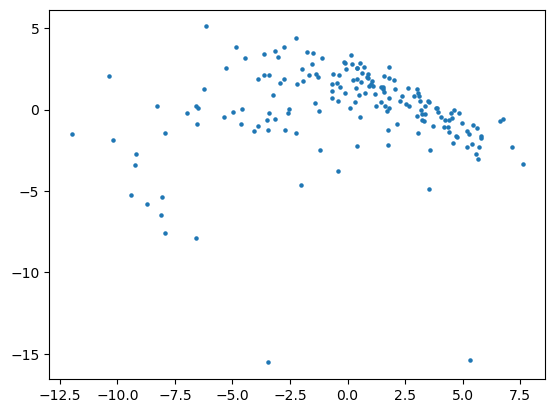

In [176]:
plt.scatter(pca_result[:,0], pca_result[:,1], s = 5)

In [177]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components = 2, random_state = 1729) 
tsne_result = tsne.fit_transform(scaled_data)

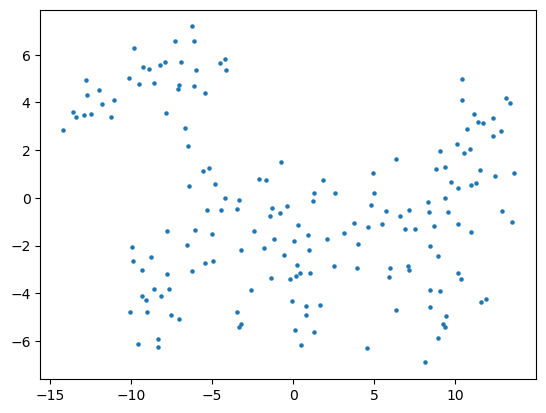

In [178]:
plt.scatter(tsne_result[:,0], tsne_result[:,1], s=5)

In [179]:
pca = PCA(n_components=25)
pca_res = pca.fit_transform(scaled_data)

In [180]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components = 2, random_state = 1729) 
tsne_result = tsne.fit_transform(pca_res)

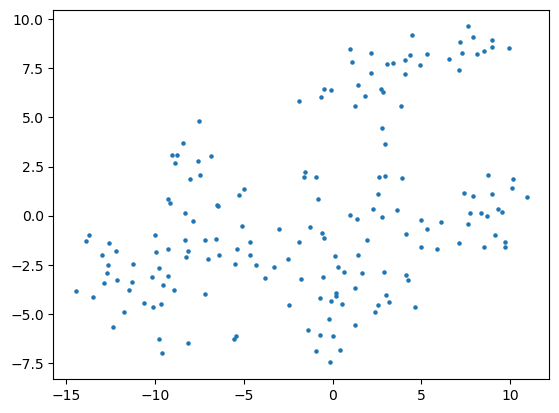

In [181]:
plt.scatter(tsne_result[:,0], tsne_result[:,1], s=5)

c:\Users\Aman Kumar Singh\anaconda3\envs\text_analytics\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


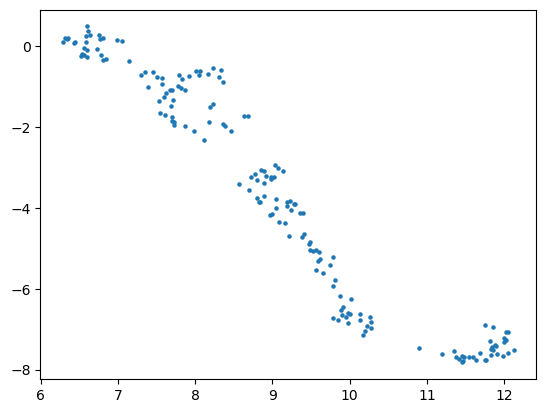

In [269]:
from umap.umap_ import UMAP
umap = UMAP(n_components=5,min_dist=0.01, random_state=400)
embedding = umap.fit_transform(scaled_data)
plt.scatter(embedding[:,0], embedding[:,1], s=5)

In [189]:
# from umap.umap_ import UMAP
# umap = UMAP()
# embedding = umap.fit_transform(scaled_data)

<Axes: xlabel='Col1', ylabel='Col2'>

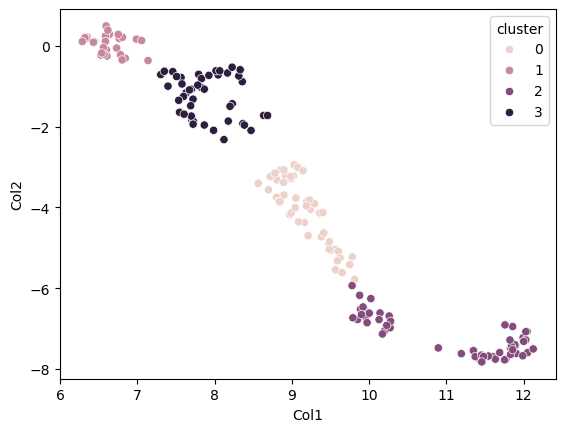

In [268]:
from sklearn.cluster import KMeans
kmean = KMeans(n_clusters=4, random_state=1429)
cluster_label = kmean.fit_predict(embedding)
embedds = pd.DataFrame({"Col1": embedding[:,0], "Col2" : embedding[:,1], "cluster": cluster_label})
sns.scatterplot(data = embedds, x = "Col1", y = "Col2", hue = "cluster")

In [232]:
cluster_label

array([1, 2, 2, 2, 3, 2, 2, 2, 0, 2, 2, 2, 2, 2, 1, 1, 2, 1, 3, 2, 2, 0,
       2, 2, 0, 2, 2, 2, 2, 1, 2, 0, 2, 2, 2, 3, 0, 2, 1, 0, 3, 2, 2, 2,
       0, 2, 2, 2, 0, 2, 2, 0, 0, 3, 1, 1, 3, 1, 1, 3, 3, 2, 1, 1, 1, 2,
       0, 2, 2, 1, 2, 2, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 3, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 3, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 3, 1,
       1, 1, 1, 1, 1, 0, 0, 3, 3, 3, 0, 1, 1, 1, 3, 1, 3, 3, 1, 3, 3, 3,
       3, 3, 1, 1, 3, 3, 3, 3, 0, 2, 2, 1, 0, 2, 2, 2, 2, 2, 3, 2])

In [250]:
embedds = pd.DataFrame({"Col1": embedding[:,0], "Col2" : embedding[:,1], "cluster": cluster_label})

In [234]:
import seaborn as sns

<Axes: xlabel='Col1', ylabel='Col2'>

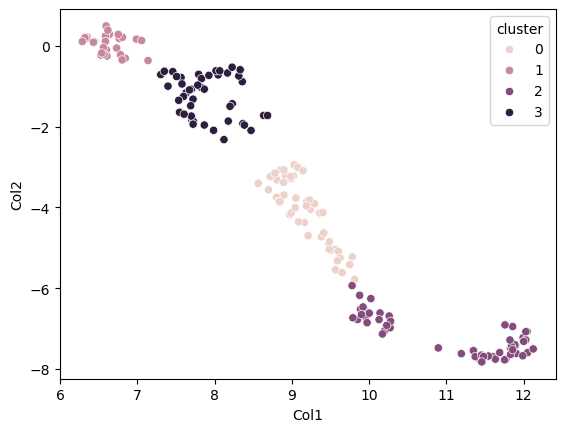

In [251]:
sns.scatterplot(data = embedds, x = "Col1", y = "Col2", hue = "cluster")

In [248]:
merged_df = pd.read_csv("merged_data.csv")

In [288]:
merged_df.head(5)

,geography,geography code,Rural Urban,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,Cars: 2 cars or vans in household; measures: Value,Cars: 3 cars or vans in household; measures: Value,Cars: 4 or more cars or vans in household; measures: Value,Distance travelled to work: Less than 2km; measures: Value,Distance travelled to work: 2km to less than 5km; measures: Value,...,Age: Age 18 to 19; measures: Value,Age: Age 20 to 24; measures: Value,Age: Age 25 to 29; measures: Value,Age: Age 30 to 44; measures: Value,Age: Age 45 to 59; measures: Value,Age: Age 60 to 64; measures: Value,Age: Age 65 to 74; measures: Value,Age: Age 75 to 84; measures: Value,Age: Age 85 to 89; measures: Value,Age: Age 90 and over; measures: Value
0,Darlington,E06000005,Total,13052,20682,10450,1962,524,11433,12516,...,2357,6071,6607,20917,21560,6685,9717,6172,1740,810
1,County Durham,E06000047,Total,60926,96086,52740,10775,3276,36588,31877,...,15278,35155,30628,96150,108200,35395,50883,30635,7321,3506
2,Hartlepool,E06000001,Total,14268,16573,7662,1535,396,8452,10557,...,2451,5955,5622,16869,19326,5837,8174,5568,1323,533
3,Middlesbrough,E06000002,Total,21488,22963,10207,1945,600,10393,15799,...,4506,11690,9765,25414,27065,7531,10833,7393,1658,807
4,Northumberland,E06000057,Total,30543,60875,36916,7671,2529,25944,14491,...,6992,16224,16187,56156,71135,24533,34366,21018,5233,2687


In [263]:
merged_df.columns = ['Unnamed: 0',
 'geography',
 'geography code',
 'Rural Urban',
 'No Cars and Vans',
 '1 Car or Van',
 '(2, 3, 4) Car or Van',
 'Young 0-19',
 'Working-age 20-64',
 'Retired-age 65-90',
 'Distance (Work from home)',
 'Distance < 10 km',
 '10 km < Distance < 30 km',
 '30 km < Distanc < 60 km',
 'Unemployed',
 'Economically active',
 'Economically Inactive',
 'cluster']

In [264]:
merged_df.head(5)

,Unnamed: 0,geography,geography code,Rural Urban,No Cars and Vans,1 Car or Van,"(2, 3, 4) Car or Van",Young 0-19,Working-age 20-64,Retired-age 65-90,Distance (Work from home),Distance < 10 km,10 km < Distance < 30 km,30 km < Distanc < 60 km,Unemployed,Economically active,Economically Inactive,cluster
0,0,Darlington,E06000005,Total,13052,20682,12936,25285,61840,18439,4180,28175,9962,3529,4002,49441,23192,3
1,1,County Durham,E06000047,Total,60926,96086,66791,115369,305528,92345,20652,106475,71001,14772,17013,230088,136695,0
2,2,Hartlepool,E06000001,Total,14268,16573,9593,22821,53609,15598,2473,22415,7391,2324,5194,38319,23291,0
3,3,Middlesbrough,E06000002,Total,21488,22963,12752,36256,81465,20691,3337,37606,5418,3223,7631,55951,36969,0
4,4,Northumberland,E06000057,Total,30543,60875,47116,68489,184235,63304,17894,60003,43224,15421,10329,147939,74956,1


In [265]:
merged_df["cluster"] = cluster_label

In [270]:
merged_df["P1"] = embedding[:,0]
merged_df["P2"] = embedding[:,1]

In [271]:
merged_df.head(2)

,Unnamed: 0,geography,geography code,Rural Urban,No Cars and Vans,1 Car or Van,"(2, 3, 4) Car or Van",Young 0-19,Working-age 20-64,Retired-age 65-90,Distance (Work from home),Distance < 10 km,10 km < Distance < 30 km,30 km < Distanc < 60 km,Unemployed,Economically active,Economically Inactive,cluster,P1,P2
0,0,Darlington,E06000005,Total,13052,20682,12936,25285,61840,18439,4180,28175,9962,3529,4002,49441,23192,3,8.120296,-2.323253
1,1,County Durham,E06000047,Total,60926,96086,66791,115369,305528,92345,20652,106475,71001,14772,17013,230088,136695,0,8.916958,-3.204791


In [273]:
pf = merged_df.drop(["Unnamed: 0", "geography", "Rural Urban"], axis =1)

In [274]:
pf.head(2)

,geography code,No Cars and Vans,1 Car or Van,"(2, 3, 4) Car or Van",Young 0-19,Working-age 20-64,Retired-age 65-90,Distance (Work from home),Distance < 10 km,10 km < Distance < 30 km,30 km < Distanc < 60 km,Unemployed,Economically active,Economically Inactive,cluster,P1,P2
0,E06000005,13052,20682,12936,25285,61840,18439,4180,28175,9962,3529,4002,49441,23192,3,8.120296,-2.323253
1,E06000047,60926,96086,66791,115369,305528,92345,20652,106475,71001,14772,17013,230088,136695,0,8.916958,-3.204791


In [284]:
cleaned_df = merged_df.merge(pf, on="geography code", how = "inner")

In [285]:
cleaned_df.head(4)

,geography,geography code,Rural Urban,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,Cars: 2 cars or vans in household; measures: Value,Cars: 3 cars or vans in household; measures: Value,Cars: 4 or more cars or vans in household; measures: Value,Distance travelled to work: Less than 2km; measures: Value,Distance travelled to work: 2km to less than 5km; measures: Value,...,Distance (Work from home),Distance < 10 km,10 km < Distance < 30 km,30 km < Distanc < 60 km,Unemployed,Economically active,Economically Inactive,cluster,P1,P2
0,Darlington,E06000005,Total,13052,20682,10450,1962,524,11433,12516,...,4180,28175,9962,3529,4002,49441,23192,3,8.120296,-2.323253
1,County Durham,E06000047,Total,60926,96086,52740,10775,3276,36588,31877,...,20652,106475,71001,14772,17013,230088,136695,0,8.916958,-3.204791
2,Hartlepool,E06000001,Total,14268,16573,7662,1535,396,8452,10557,...,2473,22415,7391,2324,5194,38319,23291,0,9.162120,-4.377292
3,Middlesbrough,E06000002,Total,21488,22963,10207,1945,600,10393,15799,...,3337,37606,5418,3223,7631,55951,36969,0,9.813269,-5.781488


In [277]:
final_df.head(2)

,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,Cars: 2 cars or vans in household; measures: Value,Cars: 3 cars or vans in household; measures: Value,Cars: 4 or more cars or vans in household; measures: Value,Distance travelled to work: Less than 2km; measures: Value,Distance travelled to work: 2km to less than 5km; measures: Value,Distance travelled to work: 5km to less than 10km; measures: Value,Distance travelled to work: 10km to less than 20km; measures: Value,Distance travelled to work: 20km to less than 30km; measures: Value,...,Age: Age 18 to 19; measures: Value,Age: Age 20 to 24; measures: Value,Age: Age 25 to 29; measures: Value,Age: Age 30 to 44; measures: Value,Age: Age 45 to 59; measures: Value,Age: Age 60 to 64; measures: Value,Age: Age 65 to 74; measures: Value,Age: Age 75 to 84; measures: Value,Age: Age 85 to 89; measures: Value,Age: Age 90 and over; measures: Value
0,13052,20682,10450,1962,524,11433,12516,4226,5552,4410,...,2357,6071,6607,20917,21560,6685,9717,6172,1740,810
1,60926,96086,52740,10775,3276,36588,31877,38010,51191,19810,...,15278,35155,30628,96150,108200,35395,50883,30635,7321,3506


In [266]:
merged_df.iloc[:, 4:].groupby("cluster").mean()

,No Cars and Vans,1 Car or Van,"(2, 3, 4) Car or Van",Young 0-19,Working-age 20-64,Retired-age 65-90,Distance (Work from home),Distance < 10 km,10 km < Distance < 30 km,30 km < Distanc < 60 km,Unemployed,Economically active,Economically Inactive
cluster,,,,,,,,,,,,,
0,29241.000000,42747.306122,28062.469388,60125.693878,140941.530612,38745.061224,8152.897959,62007.489796,21316.367347,6066.632653,9664.591837,106820.408163,57652.204082
1,23929.000000,56810.444444,48837.777778,65426.037037,168922.777778,64769.481481,19676.037037,63546.518519,31566.074074,13575.333333,7464.000000,141436.185185,68385.000000
2,43450.566038,46529.735849,22568.207547,67363.660377,174565.528302,33465.377358,11444.830189,76473.301887,23977.283019,6059.150943,10629.641509,132896.886792,62900.622642
3,35733.288889,83712.577778,80551.911111,114390.822222,282295.400000,84491.644444,26370.866667,112072.044444,54021.600000,25202.666667,12468.266667,239196.022222,99146.333333


<Axes: ylabel='cluster'>

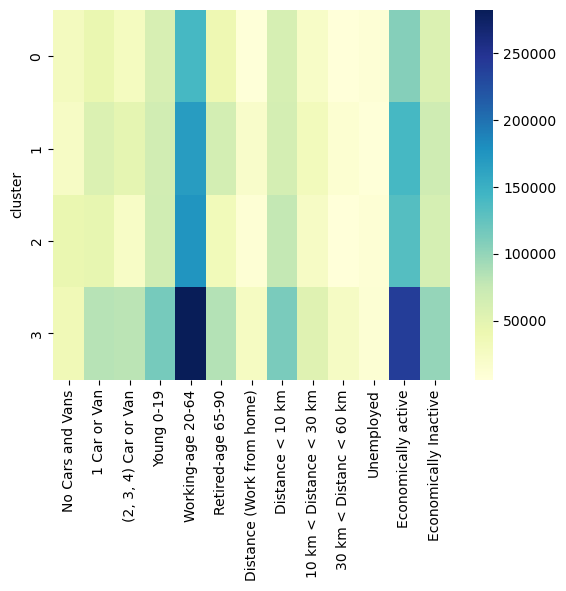

In [267]:
sns.heatmap(merged_df.iloc[:, 4:].groupby("cluster").mean(), annot=False, fmt=".0f", cmap='YlGnBu')

In [259]:
from sklearn.preprocessing import StandardScaler
scalarf = StandardScaler()
scaledf = scalarf.fit_transform(final_df)


In [ ]:
final_df

In [286]:
pf.head(4)

,geography code,No Cars and Vans,1 Car or Van,"(2, 3, 4) Car or Van",Young 0-19,Working-age 20-64,Retired-age 65-90,Distance (Work from home),Distance < 10 km,10 km < Distance < 30 km,30 km < Distanc < 60 km,Unemployed,Economically active,Economically Inactive,cluster,P1,P2
0,E06000005,13052,20682,12936,25285,61840,18439,4180,28175,9962,3529,4002,49441,23192,3,8.120296,-2.323253
1,E06000047,60926,96086,66791,115369,305528,92345,20652,106475,71001,14772,17013,230088,136695,0,8.916958,-3.204791
2,E06000001,14268,16573,9593,22821,53609,15598,2473,22415,7391,2324,5194,38319,23291,0,9.162120,-4.377292
3,E06000002,21488,22963,12752,36256,81465,20691,3337,37606,5418,3223,7631,55951,36969,0,9.813269,-5.781488


In [287]:
cleaned_df.to_csv("Data.csv")
